In [97]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

In [98]:


df = pd.read_csv('../dataset/synthetic_fraud_dataset.csv')

df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [99]:

print(df.shape)

df.info()


(50000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  fl

In [100]:
df.describe()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.05020,0.098400,7.485240,255.271924,2.003540,119.999940,2499.164155,0.501556,0.299640,0.321340
std,98.687292,28760.458557,0.21836,0.297858,4.039637,141.382279,1.414273,68.985817,1442.013834,0.287774,0.458105,0.466996
min,0.000000,500.480000,0.00000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
25%,28.677500,25355.995000,0.00000,0.000000,4.000000,132.087500,1.000000,60.000000,1256.497500,0.254000,0.000000,0.000000
50%,69.660000,50384.430000,0.00000,0.000000,7.000000,256.085000,2.000000,120.000000,2490.785000,0.502250,0.000000,0.000000
75%,138.852500,75115.135000,0.00000,0.000000,11.000000,378.032500,3.000000,180.000000,3746.395000,0.749525,1.000000,1.000000
max,1174.140000,99998.310000,1.00000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000


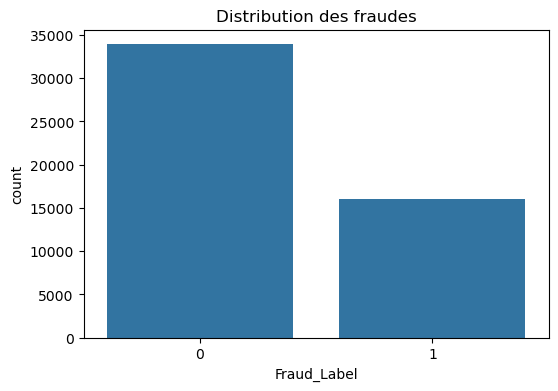

In [101]:


plt.figure(figsize=(6,4))

sns.countplot(x='Fraud_Label', data=df)

plt.title("Distribution des fraudes")

plt.show()

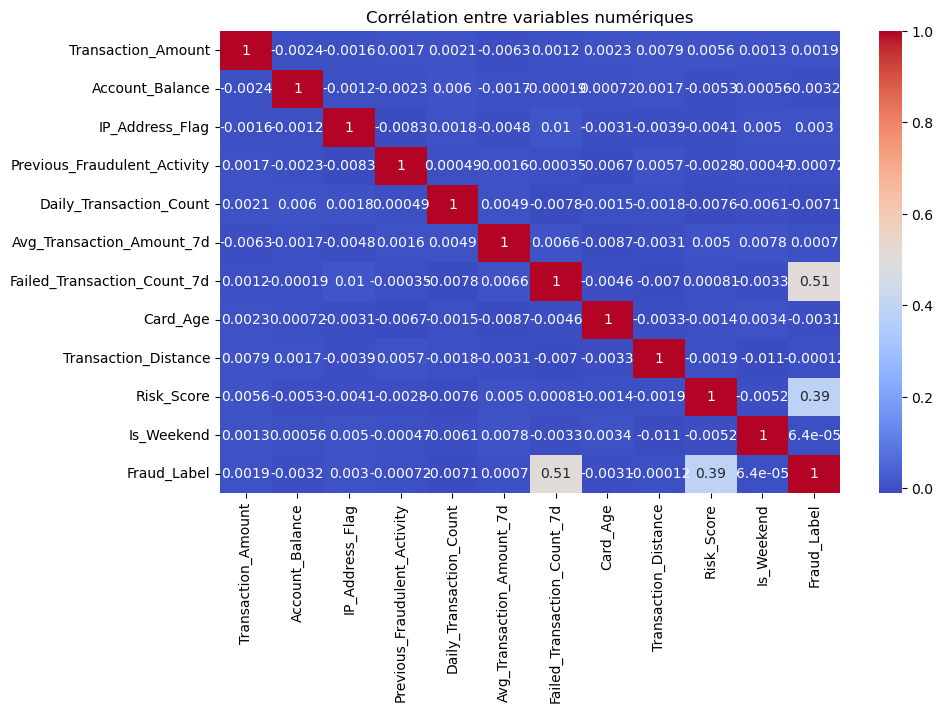

In [102]:

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Corrélation entre variables numériques")

plt.show()

In [103]:


df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['heure'] = df['Timestamp'].dt.hour

df['ecart_montant'] = (
    df['Transaction_Amount']
    - df['Avg_Transaction_Amount_7d']
)

In [104]:


features = [
    'Transaction_Amount',
    'Transaction_Type',
    'Location',
    'Account_Balance',
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d',
    'Failed_Transaction_Count_7d',
    'heure',
    'ecart_montant'
]

target = 'Fraud_Label'

df_model = df[features + [target]]

df_model.head()


,Transaction_Amount,Transaction_Type,Location,Account_Balance,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,heure,ecart_montant,Fraud_Label
0,39.79,POS,Sydney,93213.17,7,437.63,3,19,-397.84,0
1,1.19,Bank Transfer,New York,75725.25,13,478.76,4,4,-477.57,1
2,28.96,Online,Mumbai,1588.96,14,50.01,4,15,-21.05,1
3,254.32,ATM Withdrawal,New York,76807.20,8,182.48,4,0,71.84,1
4,31.28,POS,Mumbai,92354.66,14,328.69,4,23,-297.41,1


In [105]:


df_model = df_model.rename(columns={
    'Transaction_Amount': 'montant',
    'Transaction_Type': 'type_transaction',
    'Location': 'lieu',
    'Account_Balance': 'solde_compte',
    'Daily_Transaction_Count': 'frequence_24h',
    'Avg_Transaction_Amount_7d': 'montant_moyen',
    'Failed_Transaction_Count_7d': 'tentatives_pin',
    'Fraud_Label': 'fraude'
})

df_model.head()

,montant,type_transaction,lieu,solde_compte,frequence_24h,montant_moyen,tentatives_pin,heure,ecart_montant,fraude
0,39.79,POS,Sydney,93213.17,7,437.63,3,19,-397.84,0
1,1.19,Bank Transfer,New York,75725.25,13,478.76,4,4,-477.57,1
2,28.96,Online,Mumbai,1588.96,14,50.01,4,15,-21.05,1
3,254.32,ATM Withdrawal,New York,76807.20,8,182.48,4,0,71.84,1
4,31.28,POS,Mumbai,92354.66,14,328.69,4,23,-297.41,1


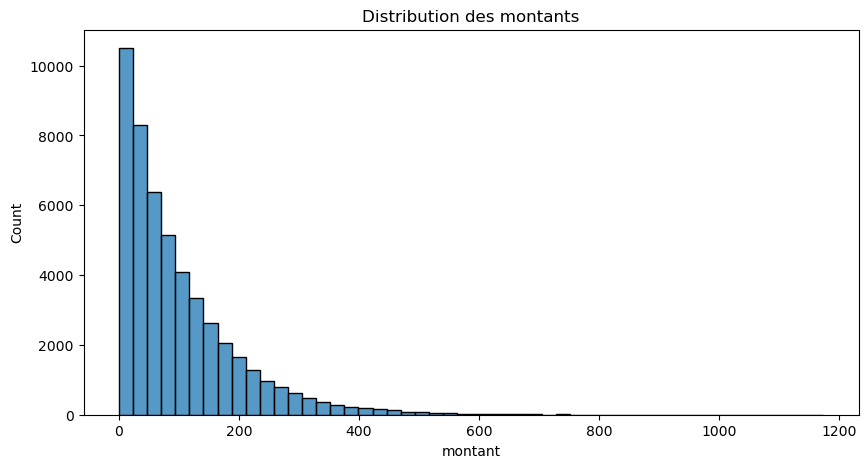

In [106]:


plt.figure(figsize=(10,5))

sns.histplot(df_model['montant'], bins=50)

plt.title("Distribution des montants")

plt.show()

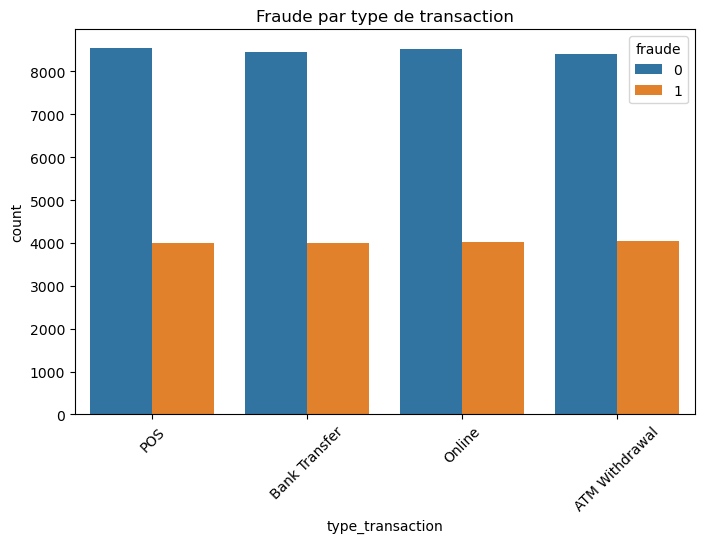

In [107]:


plt.figure(figsize=(8,5))

sns.countplot(
    x='type_transaction',
    hue='fraude',
    data=df_model
)

plt.title("Fraude par type de transaction")

plt.xticks(rotation=45)

plt.show()

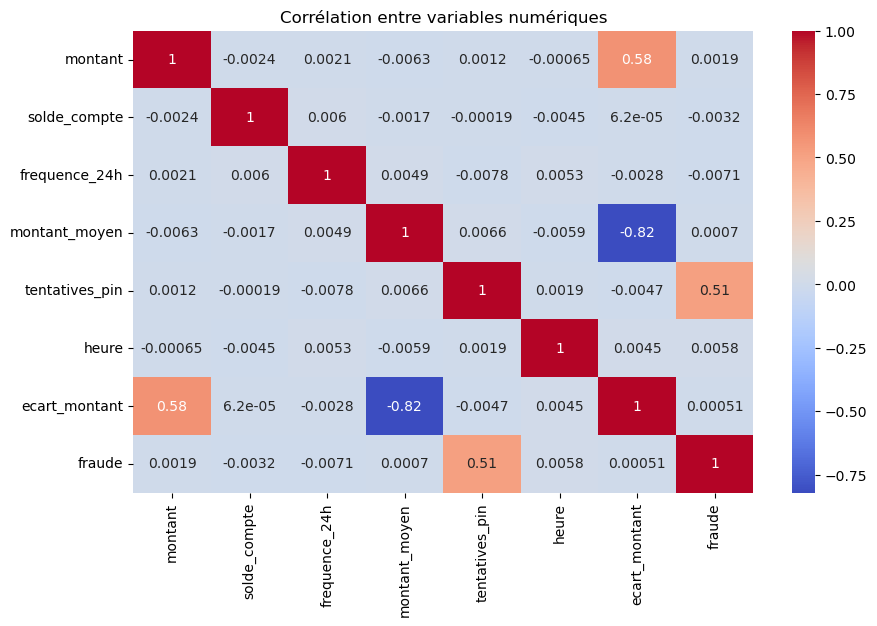

In [108]:


plt.figure(figsize=(10,6))

sns.heatmap(
    df_model.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Corrélation entre variables numériques")

plt.show()

In [109]:


df_encoded = pd.get_dummies(
    df_model,
    columns=['type_transaction', 'lieu'],
    drop_first=True
)

df_encoded.head()

,montant,solde_compte,frequence_24h,montant_moyen,tentatives_pin,heure,ecart_montant,fraude,type_transaction_Bank Transfer,type_transaction_Online,type_transaction_POS,lieu_Mumbai,lieu_New York,lieu_Sydney,lieu_Tokyo
0,39.79,93213.17,7,437.63,3,19,-397.84,0,False,False,True,False,False,True,False
1,1.19,75725.25,13,478.76,4,4,-477.57,1,True,False,False,False,True,False,False
2,28.96,1588.96,14,50.01,4,15,-21.05,1,False,True,False,True,False,False,False
3,254.32,76807.20,8,182.48,4,0,71.84,1,False,False,False,False,True,False,False
4,31.28,92354.66,14,328.69,4,23,-297.41,1,False,False,True,True,False,False,False


In [110]:


X = df_encoded.drop('fraude', axis=1)

y = df_encoded['fraude']

print(X.shape)

print(y.shape)

(50000, 14)
(50000,)


In [111]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [112]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [113]:


model = LogisticRegression(
    solver='liblinear',
    penalty='l2',
    class_weight='balanced',
    max_iter=1000
)
model.fit(X_train_scaled, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [114]:


y_pred = model.predict(X_test_scaled)

y_proba = model.predict_proba(X_test_scaled)[:,1]

In [115]:


print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1-score :", f1_score(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_proba))

Accuracy : 0.7281
Precision : 0.560068093385214
Recall : 0.7167755991285403
F1-score : 0.6288054607508532
ROC-AUC : 0.8020682791394966


In [116]:


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.73      0.79      6787
           1       0.56      0.72      0.63      3213

    accuracy                           0.73     10000
   macro avg       0.70      0.73      0.71     10000
weighted avg       0.75      0.73      0.74     10000



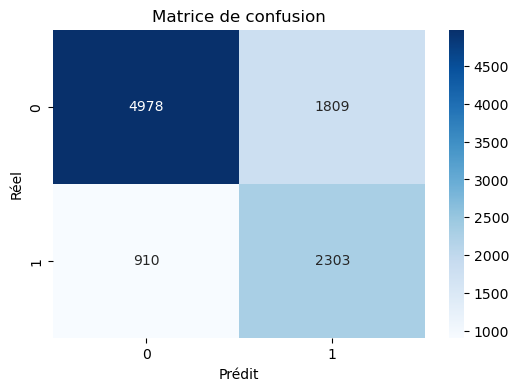

In [117]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Prédit")

plt.ylabel("Réel")

plt.title("Matrice de confusion")

plt.show()

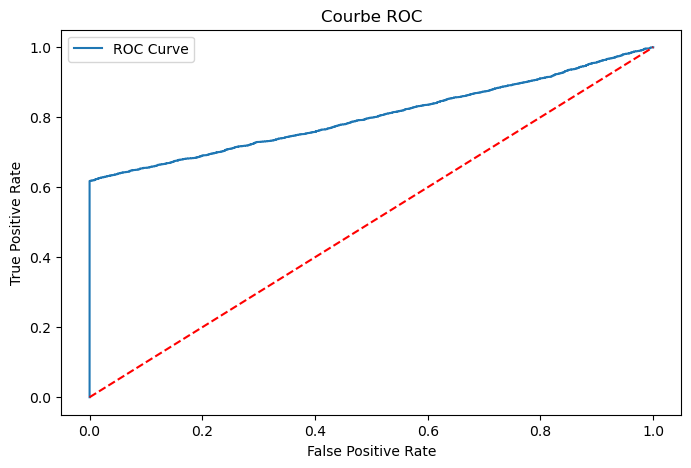

In [118]:


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Courbe ROC")

plt.legend()

plt.show()

In [119]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, y_proba)

print("Log Loss :", loss)

Log Loss : 0.5417381848478587


In [120]:


joblib.dump(model, '../model/model.pkl')

['../model/model.pkl']

In [121]:


joblib.dump(scaler, '../model/scaler.pkl')

['../model/scaler.pkl']

In [122]:


joblib.dump(X.columns.tolist(), '../model/features.pkl')

['../model/features.pkl']